**Laboratory Exercise for Lab7**

Neural Networks and Deep Learning For HVAC FAULT DETECTION AND DIAGNOSTICS

Reg-No: 23/EG/CO/027

In [1]:
# Import Libraries
%matplotlib inline
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
%matplotlib inline

In [2]:
# Check Tensor flow version
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
# Read dataset
file_path = "../datasets/raw/SZCAV.csv"
data = pd.read_csv(file_path)
data.head()

,Datetime,AHU: Supply Air Temperature,AHU: Supply Air Temperature Heating Set Point,AHU: Supply Air Temperature Cooling Set Point,AHU: Outdoor Air Temperature,AHU: Mixed Air Temperature,AHU: Return Air Temperature,AHU: Supply Air Fan Status,AHU: Supply Air Fan Speed Control Signal,AHU: Outdoor Air Damper Control Signal,AHU: Return Air Damper Control Signal,AHU: Exhaust Air Damper Control Signal,AHU: Cooling Coil Valve Control Signal,AHU: Heating Coil Valve Control Signal,Occupancy Mode Indicator,Fault Detection Ground Truth
0,3/11/2017 0:00,72.99,50.0,86.0,62.57,72.11,72.36,1,0.5,0.0,1.0,0.0,0.0,0.0,0,1
1,3/11/2017 0:01,72.98,50.0,86.0,62.57,72.11,72.36,1,0.5,0.0,1.0,0.0,0.0,0.0,0,1
2,3/11/2017 0:02,72.99,50.0,86.0,62.57,72.11,72.36,1,0.5,0.0,1.0,0.0,0.0,0.0,0,1
3,3/11/2017 0:03,72.97,50.0,86.0,62.57,72.1,72.35,1,0.5,0.0,1.0,0.0,0.0,0.0,0,1
4,3/11/2017 0:04,72.97,50.0,86.0,62.57,72.1,72.35,1,0.5,0.0,1.0,0.0,0.0,0.0,0,1


In [4]:
# View columns to understand feature available
print(data.columns)

Index(['Datetime', 'AHU: Supply Air Temperature',
       'AHU: Supply Air Temperature Heating Set Point',
       'AHU: Supply Air Temperature Cooling Set Point',
       'AHU: Outdoor Air Temperature', 'AHU: Mixed Air Temperature',
       'AHU: Return Air Temperature', 'AHU: Supply Air Fan Status',
       'AHU: Supply Air Fan Speed Control Signal',
       'AHU: Outdoor Air Damper Control Signal  ',
       'AHU: Return Air Damper Control Signal',
       'AHU: Exhaust Air Damper Control Signal    ',
       'AHU: Cooling Coil Valve Control Signal',
       'AHU: Heating Coil Valve Control Signal', 'Occupancy Mode Indicator',
       'Fault Detection Ground Truth'],
      dtype='object')


In [5]:
# Standardize the column names for easier access
data.columns = [
    "datetime",
    "supply_air_temp",
    "supply_air_temp_heating_sp",
    "supply_air_temp_cooling_sp",
    "outdoor_air_temp",
    "mixed_air_temp",
    "return_air_temp",
    "supply_fan_status",
    "supply_fan_speed_ctrl_sig",
    "outdoor_damper_ctrl_sig",
    "return_damper_ctrl_sig",
    "exhaust_damper_ctrl_sig",
    "cooling_valve_ctrl_sig",
    "heating_valve_ctrl_sig",
    "occupancy_mode",
    "faulted"
    ]

data.faulted.unique()


array([1, 0])

In [6]:
# Exploratory Data Analytics with yData profiling tool
from data_profiling import ProfileReport
profile = ProfileReport(data, title="Fault Analysis Data Profiling Report",
explorative=True)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:15<00:00,  1.04it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
# Identify the numerical categorical features in the dataset
print(data.info())
list(data.mixed_air_temp.unique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   datetime                    21600 non-null  object 
 1   supply_air_temp             21600 non-null  float64
 2   supply_air_temp_heating_sp  21600 non-null  float64
 3   supply_air_temp_cooling_sp  21600 non-null  float64
 4   outdoor_air_temp            21600 non-null  float64
 5   mixed_air_temp              21600 non-null  object 
 6   return_air_temp             21600 non-null  float64
 7   supply_fan_status           21600 non-null  int64  
 8   supply_fan_speed_ctrl_sig   21600 non-null  float64
 9   outdoor_damper_ctrl_sig     21600 non-null  float64
 10  return_damper_ctrl_sig      21600 non-null  float64
 11  exhaust_damper_ctrl_sig     21600 non-null  float64
 12  cooling_valve_ctrl_sig      21600 non-null  float64
 13  heating_valve_ctrl_sig      216

['72.11',
 '72.1',
 '72.09',
 '72.08',
 '72.07',
 '72.06',
 '72.05',
 '72.03',
 '72.02',
 '72.01',
 '72',
 '71.99',
 '71.98',
 '71.96',
 '71.94',
 '71.93',
 '71.92',
 '71.91',
 '71.9',
 '71.89',
 '71.88',
 '71.87',
 '71.86',
 '71.85',
 '71.84',
 '71.83',
 '71.82',
 '71.81',
 '71.8',
 '71.79',
 '71.78',
 '71.77',
 '71.76',
 '71.75',
 '71.74',
 '71.73',
 '71.72',
 '71.71',
 '71.7',
 '71.69',
 '71.68',
 '71.67',
 '71.66',
 '71.65',
 '71.64',
 '71.63',
 '71.62',
 '71.6',
 '71.61',
 '71.59',
 '71.57',
 '71.58',
 '71.56',
 '71.55',
 '71.54',
 '71.53',
 '71.52',
 '71.51',
 '71.5',
 '71.49',
 '71.47',
 '71.48',
 '71.46',
 '71.45',
 '71.43',
 '71.44',
 '71.42',
 '71.4',
 '71.39',
 '71.37',
 '71.38',
 '71.36',
 '71.35',
 '71.34',
 '71.33',
 '71.32',
 '71.31',
 '71.29',
 '71.3',
 '71.28',
 '71.27',
 '71.26',
 '71.25',
 '71.24',
 '71.23',
 '71.22',
 '71.21',
 '71.2',
 '71.19',
 '71.18',
 '71.17',
 '71.16',
 '71.15',
 '71.13',
 '71.14',
 '71.12',
 '71.11',
 '71.1',
 '71.09',
 '71.08',
 '71.07',
 '7

In [8]:
# Convert strings to float
data["mixed_air_temp"] = pd.to_numeric(data["mixed_air_temp"],
errors='coerce')

# Drop rows where mixed_air_temp is now NaN
data = data.dropna(subset=["mixed_air_temp"])

# Safe to cast directly to standard int now
data["mixed_air_temp"] = data["mixed_air_temp"].astype(float)
data.mixed_air_temp.unique()


C:\Users\Scientist\AppData\Local\Temp\ipykernel_16836\2363407306.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["mixed_air_temp"] = data["mixed_air_temp"].astype(float)


array([72.11, 72.1 , 72.09, ..., 69.98, 70.32, 72.2 ], shape=(2905,))

In [9]:
# Seperate target features and target variables.
X = data.drop(columns=['datetime', 'faulted'], axis=1)
y = data['faulted']


In [10]:
# View the first rows to confirm they are correctly seperated.
print(X.head)

<bound method NDFrame.head of        supply_air_temp  supply_air_temp_heating_sp  \
0                72.99                        50.0   
1                72.98                        50.0   
2                72.99                        50.0   
3                72.97                        50.0   
4                72.97                        50.0   
...                ...                         ...   
21595            71.95                        50.0   
21596            71.95                        50.0   
21597            71.93                        50.0   
21598            71.93                        50.0   
21599            71.91                        50.0   

       supply_air_temp_cooling_sp  outdoor_air_temp  mixed_air_temp  \
0                            86.0             62.57           72.11   
1                            86.0             62.57           72.11   
2                            86.0             62.57           72.11   
3                            86.0    

In [11]:
# View the first few rows of the target variable and confirm it is seperated correctly.
print(y.head())

0    1
1    1
2    1
3    1
4    1
Name: faulted, dtype: int64


In [12]:
# Split the dataset into training and test set.
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size = 0.2, random_state = 0, stratify = y)


In [13]:
# Describe the matrices of features before scaling
print(f"X_train describe: ")
X_train.describe().T

X_train describe: 


,count,mean,std,min,25%,50%,75%,max
supply_air_temp,17208.0,68.592582,7.783503,49.21,63.8500,67.55,72.540000,88.76
supply_air_temp_heating_sp,17208.0,56.309389,9.909230,50.00,50.0000,50.00,61.812500,86.00
supply_air_temp_cooling_sp,17208.0,80.373471,11.965983,50.00,86.0000,86.00,86.000000,86.00
outdoor_air_temp,17208.0,54.725957,5.355842,44.60,50.6075,53.70,57.660000,71.18
mixed_air_temp,17208.0,65.139480,5.757387,46.28,62.6300,65.24,68.000000,80.50
return_air_temp,17208.0,69.822645,5.190051,58.49,66.1900,69.14,72.332500,83.23
supply_fan_status,17208.0,0.999361,0.025276,0.00,1.0000,1.00,1.000000,1.00
supply_fan_speed_ctrl_sig,17208.0,0.499651,0.013199,0.00,0.5000,0.50,0.500000,0.50
outdoor_damper_ctrl_sig,17208.0,0.251713,0.364554,0.00,0.0000,0.15,0.150000,1.00
return_damper_ctrl_sig,17208.0,0.833141,0.366994,0.00,1.0000,1.00,1.000000,1.00


In [14]:
# Describe the matrices of features before feature scaling
print(f"X_test describe:")
X_test.describe().T

X_test describe:


,count,mean,std,min,25%,50%,75%,max
supply_air_temp,4302.0,68.551402,7.861502,49.52,63.9325,67.52,72.540000,88.83
supply_air_temp_heating_sp,4302.0,56.305602,9.812523,50.00,50.0000,50.00,62.040000,86.00
supply_air_temp_cooling_sp,4302.0,80.597903,11.776062,50.00,86.0000,86.00,86.000000,86.00
outdoor_air_temp,4302.0,54.756718,5.409974,44.60,50.5300,53.73,57.527500,71.18
mixed_air_temp,4302.0,65.220037,5.733504,46.41,62.7100,65.31,67.967500,80.87
return_air_temp,4302.0,69.821650,5.239140,58.45,66.1200,69.20,72.320000,83.10
supply_fan_status,4302.0,0.999070,0.030482,0.00,1.0000,1.00,1.000000,1.00
supply_fan_speed_ctrl_sig,4302.0,0.499768,0.010780,0.00,0.5000,0.50,0.500000,0.50
outdoor_damper_ctrl_sig,4302.0,0.245715,0.358100,0.00,0.0000,0.15,0.150000,1.00
return_damper_ctrl_sig,4302.0,0.841713,0.359641,0.00,1.0000,1.00,1.000000,1.00


In [15]:
# Print the shape of the training and test sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (17208, 14)
X_test shape: (4302, 14)
y_train shape: (17208,)
y_test shape: (4302,)


In [16]:
# Feature scale the matrix of features of the training set
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [17]:
# Print the matrix of features
print(X_train[:10])

[[ 0.63179281 -0.63673687  0.47022401  0.11278533  1.33754128  0.64304813
   0.02529123  0.0264166  -0.69048672  0.45467666 -0.45467701 -0.39579541
  -0.56320286 -1.00489342]
 [ 1.22151874 -0.63673687 -2.53839186 -1.12141678 -2.73560507  1.23072808
   0.02529123  0.0264166   2.052668   -2.27024019  2.27023972  2.67313726
  -0.56320286  0.99513041]
 [-2.37465315 -0.63673687  0.47022401  0.35551796 -0.78153699 -1.82520765
   0.02529123  0.0264166  -0.69048672  0.45467666 -0.45467701 -0.39579541
  -0.56320286 -1.00489342]
 [-0.18919821 -0.63673687  0.47022401  0.52356364  0.50901641 -0.30880071
   0.02529123  0.0264166  -0.69048672  0.45467666 -0.45467701 -0.39579541
  -0.56320286 -1.00489342]
 [ 2.38298334 -0.63673687  0.47022401 -1.25958767  1.80304372  2.44077072
   0.02529123  0.0264166   0.61853273  0.45467666 -0.45467701 -0.39579541
  -0.56320286 -1.00489342]
 [-0.11467946 -0.63673687  0.47022401  1.12666088  0.33879537 -0.50918993
   0.02529123  0.0264166  -0.69048672  0.45467666 -

In [18]:
 # Reconstruct the Dataframe from the scaled Numpy array
X_train_df = pd.DataFrame(X_train, columns=X.columns)
print(f"X_train describe:")
X_train_df.describe().T

X_train describe:


,count,mean,std,min,25%,50%,75%,max
supply_air_temp,17208.0,7.415939e-16,1.000029,-2.490286,-0.609330,-0.133952,0.507167,2.591122
supply_air_temp_heating_sp,17208.0,-4.360374e-16,1.000029,-0.636737,-0.636737,-0.636737,0.555368,2.996345
supply_air_temp_cooling_sp,17208.0,1.725981e-16,1.000029,-2.538392,0.470224,0.470224,0.470224,0.470224
outdoor_air_temp,17208.0,3.819456e-17,1.000029,-1.890693,-0.768988,-0.191564,0.547837,3.072256
mixed_air_temp,17208.0,-8.278929e-16,1.000029,-3.275796,-0.435884,0.017460,0.496858,2.668045
return_air_temp,17208.0,1.322977e-15,1.000029,-2.183596,-0.699945,-0.131533,0.483604,2.583355
supply_fan_status,17208.0,2.182251e-15,1.000029,-39.539393,0.025291,0.025291,0.025291,0.025291
supply_fan_speed_ctrl_sig,17208.0,1.130972e-15,1.000029,-37.854986,0.026417,0.026417,0.026417,0.026417
outdoor_damper_ctrl_sig,17208.0,-8.258284e-18,1.000029,-0.690487,-0.690487,-0.279014,-0.279014,2.052668
return_damper_ctrl_sig,17208.0,1.156160e-17,1.000029,-2.270240,0.454677,0.454677,0.454677,0.454677


In [19]:
# Reconstruct DataFrame from the scaled Numpy array for X_test
X_test_df = pd.DataFrame(X_test, columns=X.columns)
print(f"X_test describe:")
X_test_df.describe().T

X_test describe:


,count,mean,std,min,25%,50%,75%,max
supply_air_temp,4302.0,-0.005291,1.010050,-2.450457,-0.598730,-0.137806,0.507167,2.600116
supply_air_temp_heating_sp,4302.0,-0.000382,0.990270,-0.636737,-0.636737,-0.636737,0.578327,2.996345
supply_air_temp_cooling_sp,4302.0,0.018756,0.984157,-2.538392,0.470224,0.470224,0.470224,0.470224
outdoor_air_temp,4302.0,0.005744,1.010136,-1.890693,-0.783458,-0.185963,0.523097,3.072256
mixed_air_temp,4302.0,0.013992,0.995881,-3.253216,-0.421988,0.029618,0.491213,2.732312
return_air_temp,4302.0,-0.000192,1.009488,-2.191303,-0.713433,-0.119972,0.481195,2.558307
supply_fan_status,4302.0,-0.011496,1.206010,-39.539393,0.025291,0.025291,0.025291,0.025291
supply_fan_speed_ctrl_sig,4302.0,0.008806,0.816686,-37.854986,0.026417,0.026417,0.026417,0.026417
outdoor_damper_ctrl_sig,4302.0,-0.016453,0.982324,-0.690487,-0.690487,-0.279014,-0.279014,2.052668
return_damper_ctrl_sig,4302.0,0.023358,0.979991,-2.270240,0.454677,0.454677,0.454677,0.454677


In [38]:
# Initialize the ANN()
from tensorflow.keras.models import Sequential

In [39]:
# Set the input shape for the input layer
input_shape = (X_train.shape[1], )
print(input_shape)

(14,)


In [59]:
# Build the input layer and the first hidden layers
input_layer = tf.keras.layers.Input(shape=input_shape)

# First hidden layer with 12 neurons and ReLU activation function
hidden_layer_1 = tf.keras.layers.Dense(units=12, activation='relu')

# Second hidden layer with 8 neurons and ReLU activation function
hidden_layer_2 = tf.keras.layers.Dense(units=8, activation='relu')

# Output layer with 1 neuron and sigmoid activation function
output_layer = tf.keras.layers.Dense(units=1, activation='sigmoid')

In [60]:
# Build the ANN by adding the layers to the Sequential() Class
model = Sequential([input_layer, hidden_layer_1, hidden_layer_2,
output_layer])


In [61]:
# Get the architecture summary
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 12)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 293 (1.14 KB)

 Trainable params: 293 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Compile the ANN model
model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
loss=tf.keras.losses.BinaryCrossentropy(),
metrics=['accuracy'])

In [63]:
# Train the ANN on the training set
history = model.fit(X_train, y_train,
    batch_size=256,
    epochs = 100,
    validation_split=0.2,
    verbose=1)


Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6040 - loss: 0.6950 - val_accuracy: 0.8983 - val_loss: 0.5737
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9288 - loss: 0.4689 - val_accuracy: 0.9309 - val_loss: 0.3819
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9345 - loss: 0.3238 - val_accuracy: 0.9309 - val_loss: 0.2811
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9345 - loss: 0.2491 - val_accuracy: 0.9309 - val_loss: 0.2301
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9345 - loss: 0.2074 - val_accuracy: 0.9309 - val_loss: 0.1979
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9345 - loss: 0.1806 - val_accuracy: 0.9309 - val_loss: 0.1753
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9345 - loss: 0.1602 - val_accuracy: 0.9309 - val_loss: 0.1565
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9345 - loss: 0.1439 - val_accuracy: 0.9311 -

I noticed that when the verbose was set to 0 - there was no output. when it was set to 1 it ran for like 100 times displaying the accuracy and loss.

Observation (Run 1): During the 100 epochs, the model gradually improved its performance. The training accuracy increased from 99.37% to 99.63%, while the training loss reduced from 0.0197 to 0.0107. The validation accuracy remained consistently high at approximately 99.6%, indicating that the model generalized well to unseen data.

Observation (Run 2): The model achieved higher performance throughout training compared to Run 1. Training accuracy improved from 99.68% to 99.92%, while the loss decreased from 0.0104 to 0.0051. The validation accuracy also improved to 99.91%, suggesting excellent generalization and stable learning.

In [29]:
# Inspect the learned parameters of the ANN
for layer in model.layers:
    weights, biases = layer.get_weights()
    print(f"\nLayer: {layer.name}")
    print(f"\nWeights:\n{weights}")
    print(f"\nBiases:\n{biases}")


Layer: dense

Weights:
[[-1.1758507  -2.1229575   1.2228618   0.1297026   0.8417236   0.29905218
  -0.07877416 -0.17210478  0.15725975 -0.59154934  0.8995504   0.28031173]
 [-0.71893495 -0.0477405  -0.64721537 -0.5502533   0.13511027  0.30728778
   0.13276328  0.47012806  0.43488044 -0.5587872   0.19531606  0.69489807]
 [ 0.60147226  0.5002224  -0.598119    0.06112231  0.14369395 -0.1407978
   0.81543547  0.8450296  -0.21069968  0.71211594 -0.6631696  -1.12609   ]
 [ 0.5605181  -0.18812573 -0.11986821 -0.08037122  0.46551877  0.85439223
  -0.66372836 -1.2143676   0.84416294  0.613282   -0.26391584  0.1599688 ]
 [ 0.30011988  0.23205201 -0.7069938   1.3748645   0.98392236  0.5626708
   0.40989113 -0.45226935 -0.09125075 -0.8500542   0.0892355   0.8151232 ]
 [ 0.97922266 -0.2322754   0.948371    0.06124239 -1.1491448   0.6964703
   2.4455876   1.7315459   0.59445345 -1.4522976   1.3500059   0.6193315 ]
 [-0.3426973   0.00546274 -0.0197821   0.15857023  0.23288493 -0.28071392
   0.500930

In [30]:
# Evaluate the ANN on the test set.
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9991 - loss: 0.0064
Test Loss: 0.00637990515679121
Test Accuracy: 0.9990702271461487


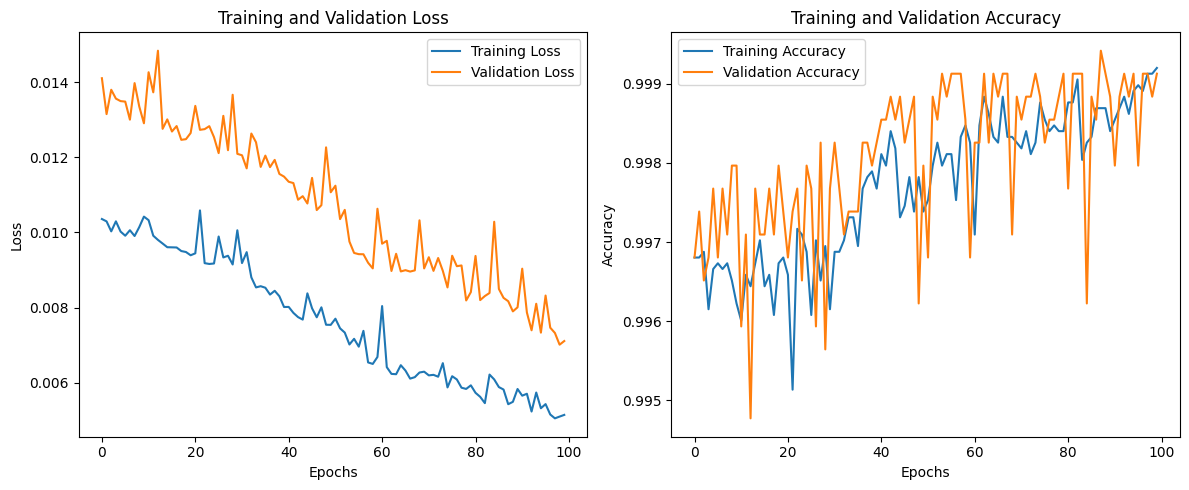

In [31]:
# Visualize the training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()



In [32]:
# Make predictions with the ANN
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [33]:
# Create a DataFrame to display the predicted probabilities
predictions = pd.DataFrame({'Probability': y_pred_prob.flatten(),
'Predicted': y_pred.flatten()})
predictions.head()

,Probability,Predicted
0,1.000000,1
1,0.999794,1
2,0.999945,1
3,1.000000,1
4,1.000000,1


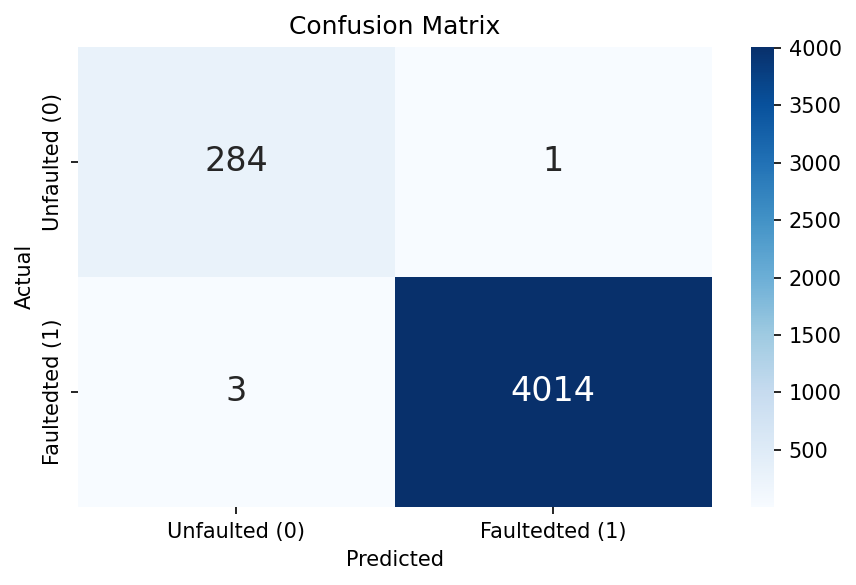

In [65]:
# Print the confusion metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
cm = confusion_matrix(y_test, y_pred)
# Plot the confusion matrix using seaborn heatmap
import seaborn as sns
plt.figure(figsize=(6, 4), dpi=150)
labels = ['Unfaulted (0)', 'Faultedted (1)']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=labels, yticklabels=labels,
annot_kws={"size": 16})
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../output/png_files/ann_confusion_matrix.png', dpi=300)
plt.show()



In [36]:
# Print the accuracy
cr = classification_report(y_test, y_pred, digits=4,
target_names=['Unfaulted (0)', 'Faultedted (1)'])
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:\n", cr)

Accuracy: 0.9991
Precision: 0.9998
Recall: 0.9993
F1-Score: 0.9995

Classification Report:
                 precision    recall  f1-score   support

 Unfaulted (0)     0.9895    0.9965    0.9930       285
Faultedted (1)     0.9998    0.9993    0.9995      4017

      accuracy                         0.9991      4302
     macro avg     0.9946    0.9979    0.9963      4302
  weighted avg     0.9991    0.9991    0.9991      4302



In [37]:
# Print the False Negative Rate
# False Negatives / (False Negatives + True Positives)
fnr = cm[1][0] / (cm[1][0] + cm[1][1])
print(f"False Negative Rate (FNR): {fnr:.4f}")

# False Positives / (True Negatives + False Positives)
fpr = cm[0][1] / (cm[0][0] + cm[0][1])
print(f"False Positive Rate (FPR): {fpr:.4f}")

False Negative Rate (FNR): 0.0007
False Positive Rate (FPR): 0.0035


Observation: Running the ANN multiple times produced consistently high performance, with only slight variations in accuracy, precision, recall, and F1-score. In this experiment, the second run achieved slightly higher accuracy and lower loss than the first run, indicating further improvement in the model's learning. These small differences may be due to random initialization of network weights, data shuffling during training, batch processing, and the stochastic nature of the Adam optimizer. Additionally, if the model is trained again without reinitialization, it continues learning from the previously learned weights, which can further improve the performance metrics.

Although the ANN consistently achieved high performance across multiple runs, slight variations were observed in the initial accuracy, final accuracy, precision, recall, F1-score, and loss values. These variations are expected because each newly created model begins with randomly initialized weights, and the training process involves stochastic optimization and shuffled training batches. Despite these small differences, all runs followed the same overall learning pattern: training and validation accuracy increased steadily while the loss decreased, demonstrating stable and effective learning.